In [ ]:
import pandas as pd
from datetime import datetime, timedelta
import os
import requests
import time
import random

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from affine import Affine
from pyproj import Proj, transform
import numpy as np
from osgeo import gdal

def reproject_to_sentinel2(src_path, dst_path, target_res=20, target_size=(512, 512)):
    with rasterio.open(src_path) as src:
        # Translated comment
        transform, width, height = calculate_default_transform(
            src.crs, src.crs, src.width, src.height, resolution=(target_res, target_res),
            left=src.bounds.left, bottom=src.bounds.bottom, right=src.bounds.right, top=src.bounds.top
        )
        
        # Translated comment
        profile = src.profile
        profile.update(
            transform=transform,
            crs=src.crs,
            width=int((src.bounds.right - src.bounds.left) / target_res),
            height=int((src.bounds.top - src.bounds.bottom) / target_res)
        )

        # Translated comment
        with rasterio.open(dst_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=src.crs,
                    resampling=Resampling.bilinear
                )

def resize_and_expand_to_512(src_path, dst_path, center_lat, center_lon, target_res=20):
    try:
        with rasterio.open(src_path) as src:
            if src.height == 0 or src.width == 0:
                return
            target_width, target_height = 512, 512
            
            # Translated comment
            new_data = np.zeros((1, target_height, target_width), dtype='uint8')
            
            # Translated comment
            data = np.zeros((src.count, src.height, src.width), dtype='uint8')
            for i in range(1, src.count + 1):
                data[i-1] = src.read(i, resampling=Resampling.bilinear)
            
            # Translated comment
            gray_data = np.max(data > 0, axis=0).astype('uint8')

            # Translated comment
            proj_wgs84 = Proj(init='epsg:4326')
            proj_utm = Proj(src.crs)
            center_x, center_y = transform(proj_wgs84, proj_utm, center_lon, center_lat)
            
            # Translated comment
            center_pixel_x = int((center_x - src.bounds.left) / target_res)
            center_pixel_y = int((src.bounds.top - center_y) / target_res)

            # Translated comment
            start_x = target_width // 2 - center_pixel_x
            start_y = target_height // 2 - center_pixel_y
            
            # Translated comment
            new_data[0, start_y:start_y + src.height, start_x:start_x + src.width] = gray_data
            
            # Translated comment
            new_transform = Affine(target_res, 0, center_x - (target_width // 2) * target_res,
                                0, -target_res, center_y + (target_height // 2) * target_res)
            profile = src.profile
            profile.update(
                transform=new_transform,
                width=target_width,
                height=target_height,
                count=1,
                dtype='uint8'
            )
            
            # Translated comment
            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(new_data)
    except Exception as e:
        print(f'{e}')

base_dir = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'
df = pd.read_csv('/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv')
for index, row in df.iterrows():
    if isinstance(row['plume_tif'], str) and len(row['plume_tif']) > 0:
        # if row['plume_id'] in ['GAO20210427t173055p0000-2', 'GAO20210429t170220p0000-1']:
        if row['plume_id'] == 'GAO20210515t145818p0000-1':
            continue
        print(f"current processing {row['plume_id']}")
        plume_dir = os.path.join(base_dir, row['plume_id'])
        input_tif = os.path.join(plume_dir, 'plume.tif')
        reprojected_tif = os.path.join(plume_dir, 'reprojected.tif')
        resized_tif = os.path.join(plume_dir, 'resized_512x512.tif')
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        # Reproject the image to match Sentinel-2 resolution
        reproject_to_sentinel2(input_tif, reprojected_tif)

        # Resize the reprojected image to 512x512
        resize_and_expand_to_512(reprojected_tif, resized_tif, center_lat = lat, center_lon = lon, target_res=20)

current processing GAO20191019t145209p0000-A
current processing GAO20191019t151221p0000-A
current processing GAO20191019t151221p0000-B
current processing GAO20191019t151221p0000-C
current processing GAO20191019t152720p0000-A
current processing GAO20191019t152720p0000-B
current processing GAO20191019t152720p0000-C
current processing GAO20191019t152720p0000-D
current processing GAO20191019t154751p0000-A
current processing GAO20191019t154751p0000-B
current processing GAO20191019t154751p0000-C
current processing GAO20191019t160217p0000-A
current processing GAO20191019t160217p0000-B
current processing GAO20191019t160217p0000-C
current processing GAO20191019t160217p0000-D
current processing GAO20191019t160217p0001-A
current processing GAO20191019t162259p0000-A
current processing GAO20191019t162259p0000-B
current processing GAO20191019t162259p0000-C
current processing GAO20191019t163802p0000-A
current processing GAO20191019t163802p0000-B
current processing GAO20191019t163802p0000-C
current pr

KeyboardInterrupt: 

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "/home/yuyao/miniconda3/envs/data/lib/python3.11/logging/__init__.py", line 1544, in log
    def log(self, level, msg, *args, **kwargs):

KeyboardInterrupt: 


current processing GAO20200721t161457p0000-A
current processing GAO20200721t161457p0000-B
current processing GAO20200721t161457p0000-C
current processing GAO20200721t161457p0000-D
current processing GAO20200721t161457p0000-E
current processing GAO20200721t161457p0000-F
current processing GAO20200721t161457p0000-G
current processing GAO20200721t161457p0000-H
current processing GAO20200721t162841p0000-A
current processing GAO20200721t162841p0000-B
current processing GAO20200721t162841p0000-C
current processing GAO20200721t162841p0000-D
current processing GAO20200721t162841p0000-E
current processing GAO20200721t162841p0000-F
current processing GAO20200721t164206p0000-A
current processing GAO20200721t165531p0000-A
current processing GAO20200721t165531p0000-B
current processing GAO20200721t165531p0000-C
current processing GAO20200721t170849p0000-A
current processing GAO20200721t170849p0000-B
current processing GAO20200721t172222p0000-A
current processing GAO20200721t172222p0000-B
current pr

current processing GAO20191019t145209p0000-A latitude 31.450855 longitude -101.75815


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

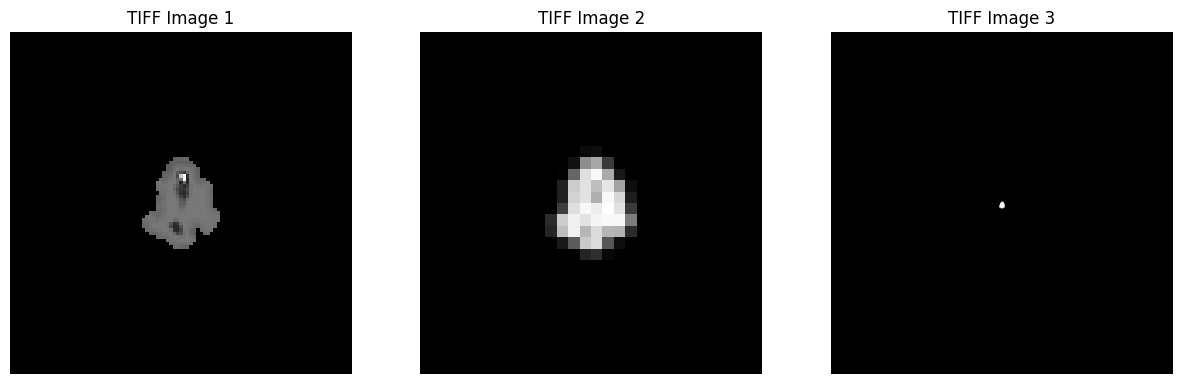

current processing GAO20191019t151221p0000-A latitude 31.4175117 longitude -102.16486


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

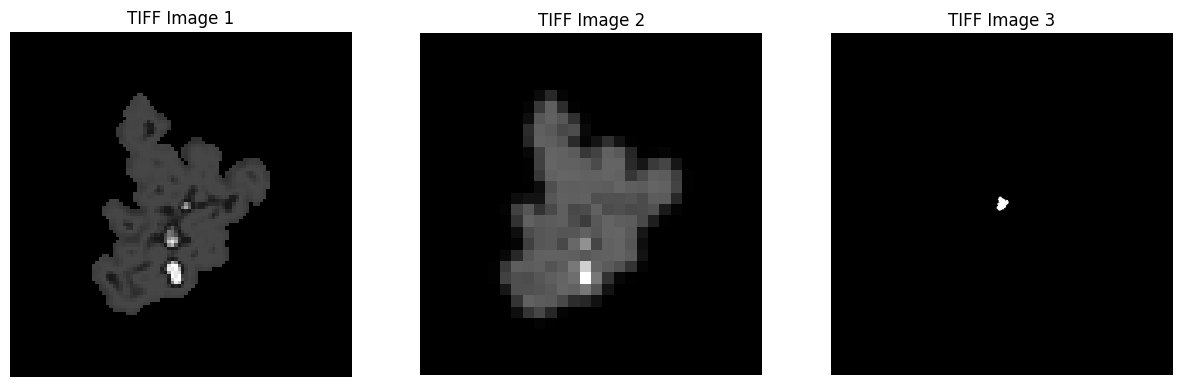

current processing GAO20191019t151221p0000-B latitude 31.410972 longitude -102.07123


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

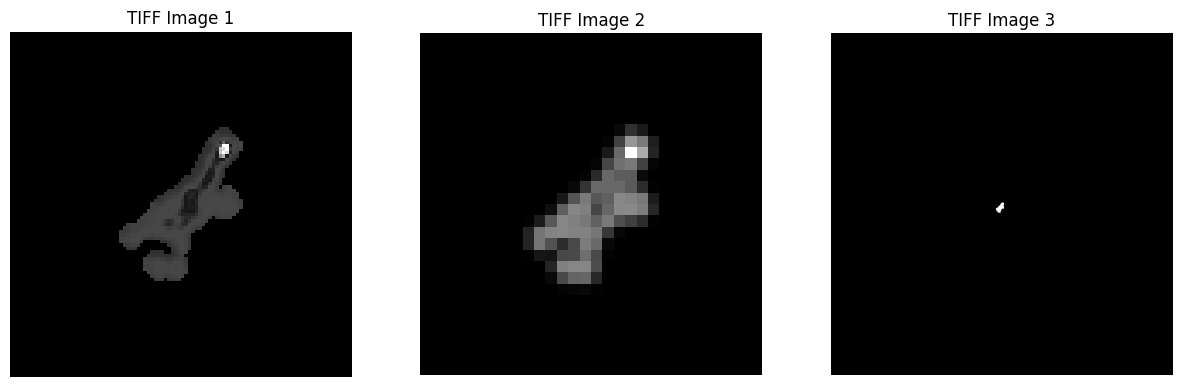

current processing GAO20191019t151221p0000-C latitude 31.423484 longitude -101.55237


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

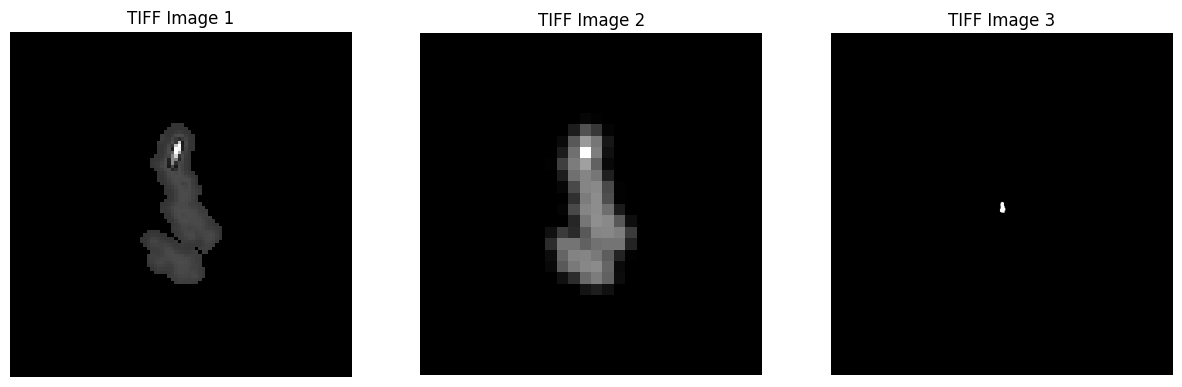

current processing GAO20191019t152720p0000-A latitude 31.39041 longitude -101.61676


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

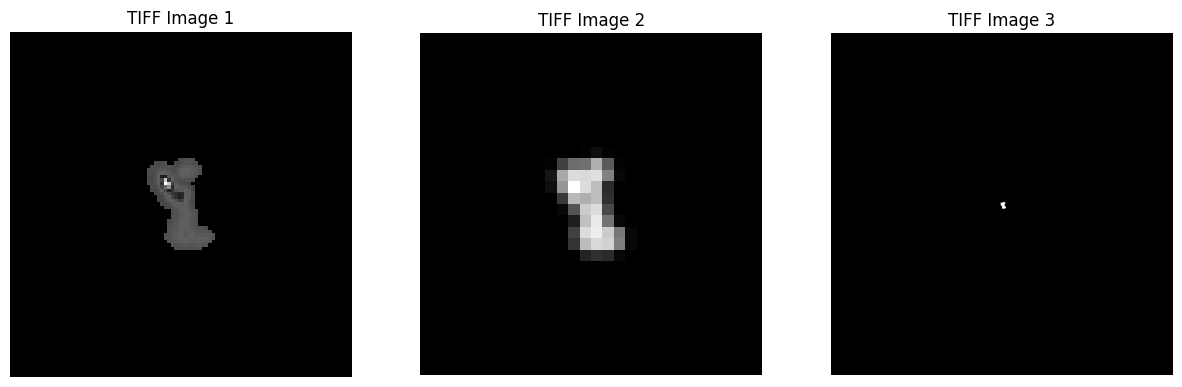

current processing GAO20191019t152720p0000-B latitude 31.4093353 longitude -101.49385


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

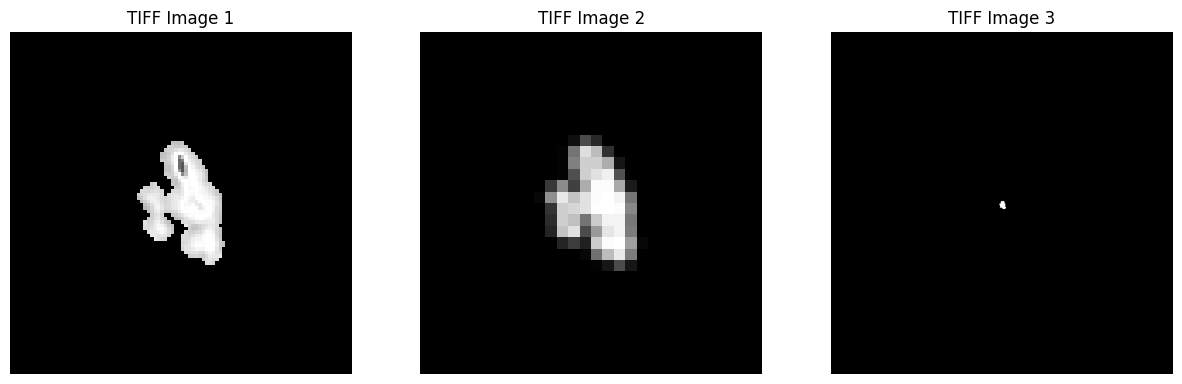

current processing GAO20191019t152720p0000-C latitude 31.395219 longitude -101.46958


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

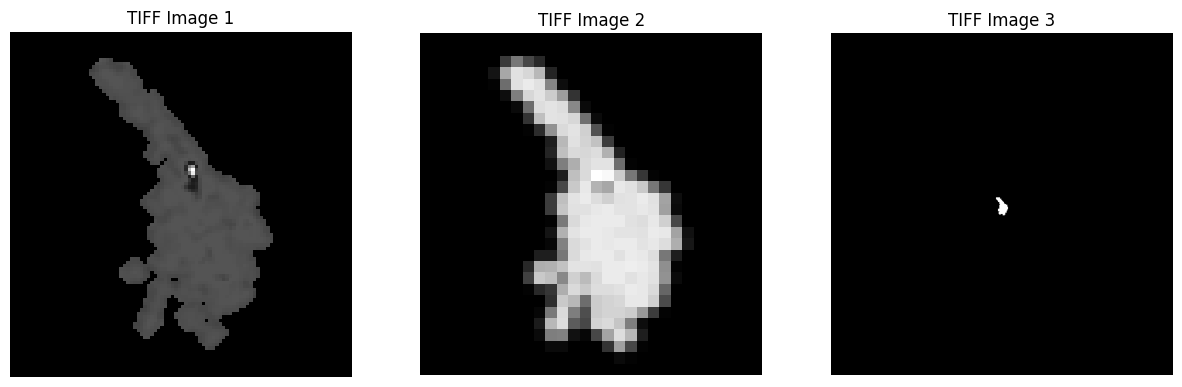

current processing GAO20191019t152720p0000-D latitude 31.3979345 longitude -101.42775


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

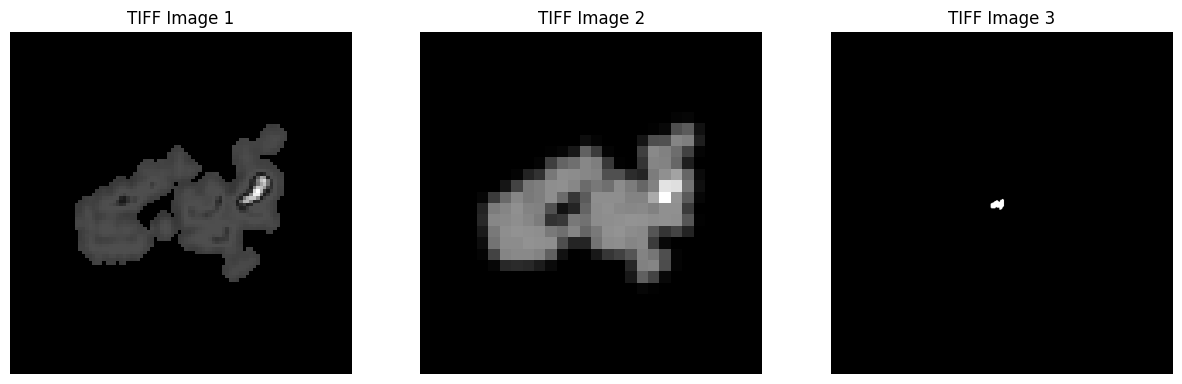

current processing GAO20191019t154751p0000-A latitude 31.367243 longitude -102.14623


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

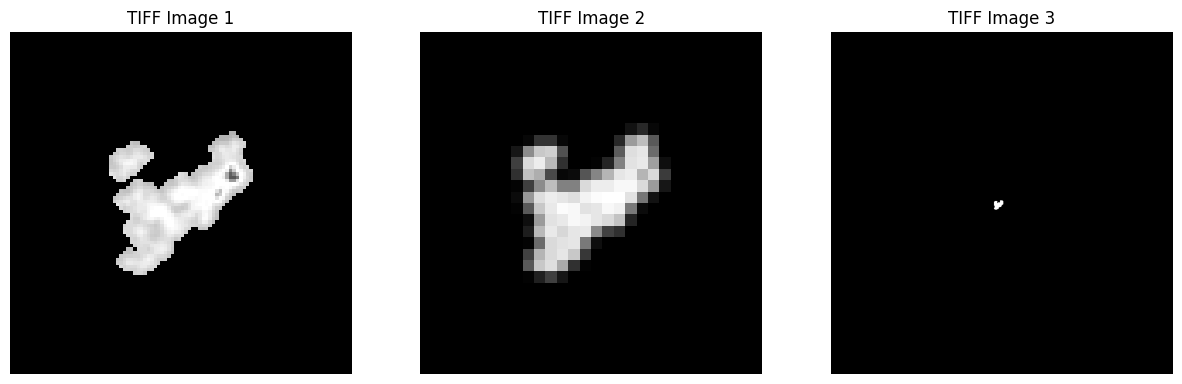

current processing GAO20191019t154751p0000-B latitude 31.362841 longitude -102.0637


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

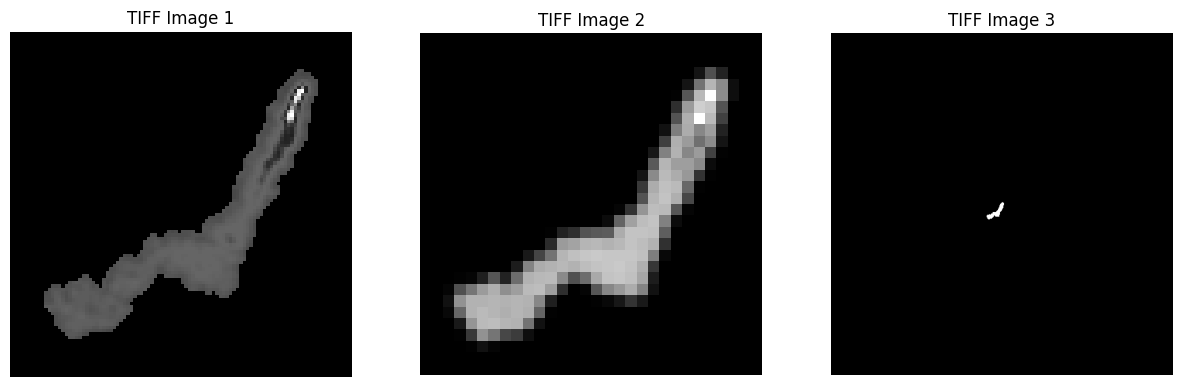

current processing GAO20191019t154751p0000-C latitude 31.370677 longitude -101.75712


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

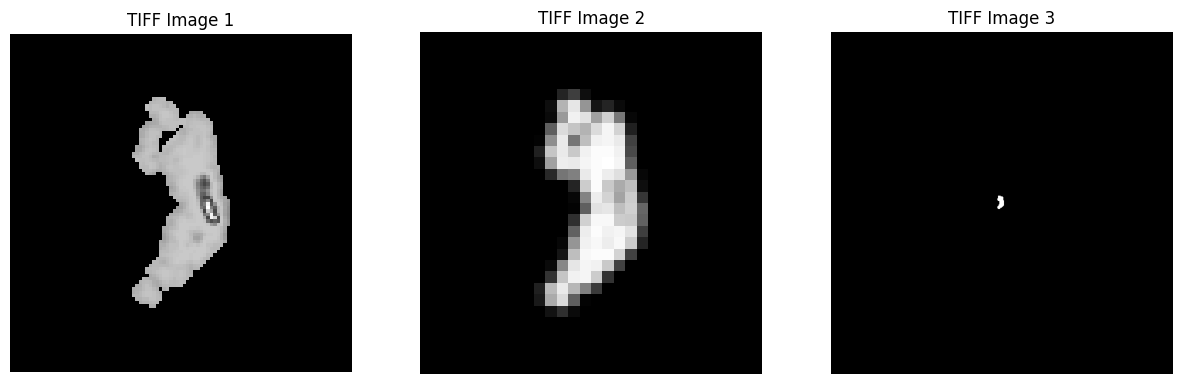

current processing GAO20191019t160217p0000-A latitude 31.345644 longitude -102.12144


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1499483/1724717698.py:38: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-cha

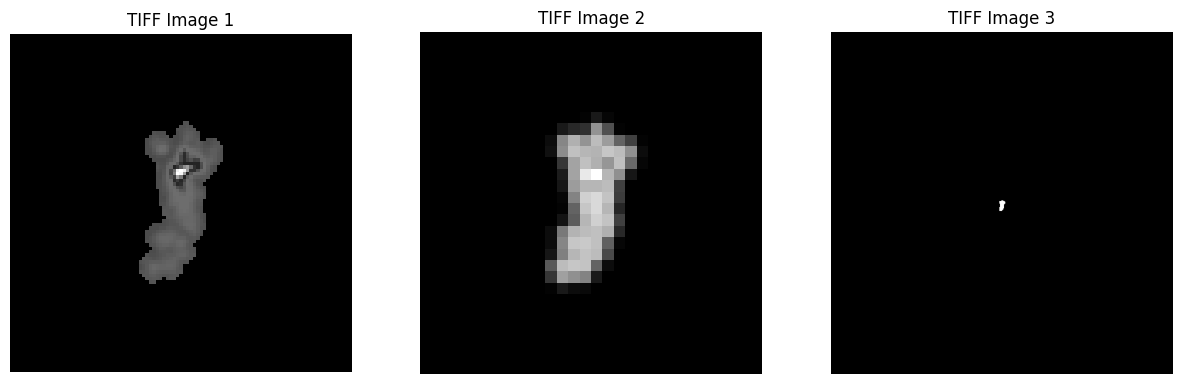

In [2]:
import pandas as pd
from datetime import datetime, timedelta
import os
import requests
import time
import random

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import Affine
from pyproj import Proj, transform
import numpy as np

import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

def get_center_latlon(tif_file):
    with rasterio.open(tif_file) as src:
        # Translated comment
        transform_matrix = src.transform
        width = src.width
        height = src.height
        
        # Translated comment
        center_x = width // 2
        center_y = height // 2
        
        # Translated comment
        center_lon, center_lat = transform_matrix * (center_x, center_y)
        
        # Translated comment
        src_crs = src.crs
        
        # Translated comment
        wgs84 = Proj(init='epsg:4326')  # Translated comment
        project = Proj(src_crs)  # Translated comment
        center_lon, center_lat = transform(project, wgs84, center_lon, center_lat)
        
        return center_lat, center_lon

base_dir = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'
df = pd.read_csv('/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv')
for index, row in df.iterrows():
    if isinstance(row['plume_tif'], str) and len(row['plume_tif']) > 0:
        if row['plume_id'] in ['GAO20210427t173055p0000-2', 'GAO20210429t170220p0000-1']:
            continue
        
        print(f"current processing {row['plume_id']} latitude {row['plume_latitude']} longitude {row['plume_longitude']}")
        plume_dir = os.path.join(base_dir, row['plume_id'])
        input_tif = os.path.join(plume_dir, 'plume.tif')
        reprojected_tif = os.path.join(plume_dir, 'reprojected.tif')
        resized_tif = os.path.join(plume_dir, 'resized_512x512.tif')

        # Open the TIFF files
        with rasterio.open(input_tif) as src1:
            img1 = src1.read(1)  # Reading the first band

        with rasterio.open(reprojected_tif) as src2:
            img2 = src2.read(1)  # Reading the first band

        with rasterio.open(resized_tif) as src3:
            img3 = src3.read(1)  # Reading the first band


        center_latlon_1 = get_center_latlon(input_tif)
        center_latlon_2 = get_center_latlon(reprojected_tif)
        center_latlon_3 = get_center_latlon(resized_tif)

        # outputresult
 print(f"TIFF Image 1 centerlat/lon: {center_latlon_1}")
 print(f"TIFF Image 2 centerlat/lon: {center_latlon_2}")
 print(f"TIFF Image 3 centerlat/lon: {center_latlon_3}")
        # Plot the images
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(img1, cmap='gray')
        axes[0].set_title('TIFF Image 1')
        axes[0].axis('off')  # Hide the axes

        axes[1].imshow(img2, cmap='gray')
        axes[1].set_title('TIFF Image 2')
        axes[1].axis('off')

        axes[2].imshow(img3, cmap='gray')
        axes[2].set_title('TIFF Image 3')
        axes[2].axis('off')

        plt.show()
        if index > 10:
            break